# Plan de Compras 2025 — Actividades

**Curso:** IA en Producción — UDLA
**Alumno:** Pablo Villegas
**Rama:** `Villegates`
**Fuente:** `plan_de_compras_2025.xlsx` (Plan Anual de Compras MINVU 2025)

Este notebook resuelve las actividades planteadas en `notebooks/README.md`:

| # | Actividad | Sección |
|---|---|---|
| — | Cargar la planilla de compras 2025 | [0](#0) |
| 1 | Realizar EDA | [1](#1) |
| 2 | Tablas de resumen | [2](#2) |
| 3 | Gráficos de resumen | [3](#3) |
| 4 | Limpieza de columnas de teléfono | [4](#4) |
| 5 | Análisis de fechas | [5](#5) |
| 6 | Filtrar por código de proyecto según año (mostrar solo año 25) | [6](#6) |

## Preámbulo — librerías y utilidades

In [1]:
%matplotlib inline
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

MM = 1_000_000
MESES = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
         "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]


def clp(x):
    """Formatea un monto en pesos chilenos."""
    return f"${x:,.0f}".replace(",", ".")


def eje_millones(ax, eje="x"):
    """Formatea el eje indicado en millones de pesos."""
    fmt = mticker.FuncFormatter(lambda v, _: f"{v / MM:,.0f}")
    (ax.xaxis if eje == "x" else ax.yaxis).set_major_formatter(fmt)

<a id="0"></a>
---
# 0. Cargar la planilla de compras 2025

In [2]:
# el .xlsx vive en la raíz del repositorio, el notebook en notebooks/
RUTA = Path("../plan_de_compras_2025.xlsx")
if not RUTA.exists():
    RUTA = Path("plan_de_compras_2025.xlsx")

df = pd.read_excel(RUTA)
print(f"Archivo : {RUTA.resolve().name}")
print(f"Filas   : {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"Hojas   : {pd.ExcelFile(RUTA).sheet_names}")

Archivo : plan_de_compras_2025.xlsx
Filas   : 831
Columnas: 26
Hojas   : ['PLAN DE COMPRAS 2025']


### Estructura general

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 831 entries, 0 to 830
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Unidad de Compra                 831 non-null    str           
 1   ID Proyecto                      831 non-null    str           
 2   Tipo Proyecto                    831 non-null    str           
 3   Estado Proyecto                  831 non-null    str           
 4   Código presupuestario            830 non-null    object        
 5   Nombre Proyecto                  831 non-null    str           
 6   Descripción Proyecto             831 non-null    str           
 7   Cantidad de Ítems                831 non-null    int64         
 8   Nombre ítem                      831 non-null    str           
 9   Tipo compra                      831 non-null    int64         
 10  Cantidad Productos               831 non-null    int64         
 11  Mont

### Primeras filas

In [4]:
df.head()

,Unidad de Compra,ID Proyecto,Tipo Proyecto,Estado Proyecto,Código presupuestario,Nombre Proyecto,Descripción Proyecto,Cantidad de Ítems,Nombre ítem,Tipo compra,Cantidad Productos,Monto Unitario Ítem,Monto Total Ítem Año 2025,Cantidad OC,Meses envío OC,Nombre responsable,Cargo responsable,Teléfono responsable,Correo responsable,Fecha de Inicio Compra,Fecha Publicación PAC 2025,Cantidad OC Asociadas Ítem 2025,OC Asociada Item 2025,Item De Arraste,Monto De Arrastre,Meses envio OC de Arraste
0,Ministerio de Vivienda y Urbanismo(766),587-259-PC22,Proyecto estratégico,Publicado,2207-2209-33,Servicio arriendo de una plataforma de gestión...,Servicio de arriendo de una plataforma de gest...,2,Servicio arriendo de una plataforma de gestión...,1,1,125000000,20000000,3,"Abr 2023,Ene 2024,Ene 2025",María Teresa Zúñiga Silva,Coordinadora de Tecnologías Informáticas | Sis...,2 -2901 1198-,mzunigas@minvu.cl,2022-11-01,2022-11-08,0,NaN,1,20000000,2025-01-01
1,SEREMI MINVU V REGION,632-28-PC22,Proyecto operacional,Publicado,2206-2206001,Servicio de Mantención y Reparaciones Menores ...,Convenio de Suministro para el Servicio de Man...,1,Mantenimiento y Reparación de Edificaciones,1,1,20000000,4500000,5,"May 2022,Nov 2022,Ene 2023,Ene 2024,Ene 2025",Ariel Gardaix Gardaix,Encargado Sección Administración y Finanzas,32-2186802-,agardaix@minvu.cl,2022-02-01,2022-11-08,1,632-7-SE22,1,4500000,2025-01-01
2,SEREMI MINVU V REGION,632-32-PC22,Proyecto operacional,Publicado,2204001,Servicios de Impresión-Seremi Valparaiso,Servicios de Impresión de Materiales SEREMI y ...,1,Materiales de Oficina,1,1,15300000,3825000,4,"Oct 2022,Ene 2023,Ene 2024,Ene 2025",Ariel Gardaix Gardaix,Encargado Sección Administración y Finanzas,32-2186802-,agardaix@minvu.cl,2022-08-01,2022-11-08,0,NaN,1,3825000,2025-01-01
3,SEREMI MINVU V REGION,632-34-PC22,Proyecto operacional,Publicado,2209006,Servicio de Arriendo de Impresoras Multifuncio...,Servicio de Arriendo de Impresoras Multifuncio...,2,Arriendo de Equipos Informáticos,1,1,18000000,4500000,6,"Oct 2022,Nov 2022,Dic 2022,Ene 2023,Ene 2024,E...",Ariel Gardaix Gardaix,Encargado Sección Administración y Finanzas,32-2186802-,agardaix@minvu.cl,2022-08-01,2022-11-08,1,632-13-CC23,1,4500000,2025-01-01
4,SEREMI MINVU V REGION,632-41-PC22,Proyecto operacional,Publicado,2205005,Servicio de Telefonía Fija-Seremi Valparaiso,Servicio de Telefonía Fija SEREMI,2,Telefonía Fija,1,1,105600000,26400000,4,"Ene 2023,Ene 2024,Ene 2025,Ene 2026",Ariel Gardaix Gardaix,Encargado Sección Administración y Finanzas,322186802,agardaix@minvu.cl,2022-12-01,2022-11-08,0,NaN,1,26400000,2025-01-01


### Nombres, tipos y cardinalidad de cada columna

In [5]:
resumen_cols = pd.DataFrame({
    "columna": df.columns,
    "tipo": [str(t) for t in df.dtypes],
    "nulos": df.isna().sum().to_numpy(),
    "unicos": [df[c].nunique(dropna=True) for c in df.columns],
})
resumen_cols

,columna,tipo,nulos,unicos
0,Unidad de Compra,str,0,16
1,ID Proyecto,str,0,326
2,Tipo Proyecto,str,0,2
3,Estado Proyecto,str,0,2
4,Código presupuestario,object,1,73
5,Nombre Proyecto,str,0,328
6,Descripción Proyecto,str,0,297
7,Cantidad de Ítems,int64,0,3
8,Nombre ítem,str,0,317
9,Tipo compra,int64,0,6


**Conclusiones de la carga**

- El libro tiene una sola hoja: **PLAN DE COMPRAS 2025**.
- Son **831 filas** (cada fila es un *ítem* de compra, no un proyecto) y **26 columnas**.
- Ya vienen tipadas como fecha: `Fecha de Inicio Compra`, `Fecha Publicación PAC 2025`
  y `Meses envio OC de Arraste`.
- `Teléfono responsable` y `Meses envío OC` llegan como texto sin formato homogéneo:
  se limpian en las actividades 4 y 5.

<a id="1"></a>
---
# 1. Análisis exploratorio de datos (EDA)

Revisión de calidad y distribución: dimensiones, tipos, nulos, duplicados,
cardinalidad y valores atípicos.

### 1.1 Dimensiones y tipos

In [6]:
print(f"Filas x Columnas: {df.shape}")
print()
print(df.dtypes.value_counts())

Filas x Columnas: (831, 26)

str               11
int64              9
object             3
datetime64[us]     3
Name: count, dtype: int64


### 1.2 Valores nulos

In [7]:
nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "pct": (df.isna().mean() * 100).round(2),
})
nulos[nulos["nulos"] > 0].sort_values("nulos", ascending=False)

,nulos,pct
Meses envio OC de Arraste,648,77.98
OC Asociada Item 2025,123,14.80
Código presupuestario,1,0.12


Solo tres columnas tienen faltantes y todos son *estructurales*, no errores:

- `Meses envio OC de Arraste`: nulo cuando el ítem **no** es de arrastre.
- `OC Asociada Item 2025`: nulo cuando aún no hay orden de compra emitida.
- `Código presupuestario`: un único registro sin dato.

### 1.3 Duplicados

In [8]:
print("Filas duplicadas completas:", df.duplicated().sum())
print("ID Proyecto distintos     :", df["ID Proyecto"].nunique())
print("Filas por proyecto (prom) :", round(len(df) / df["ID Proyecto"].nunique(), 2))

# un mismo proyecto puede aportar varios ítems: eso NO es un duplicado
df["ID Proyecto"].value_counts().head(10)

Filas duplicadas completas: 0
ID Proyecto distintos     : 326
Filas por proyecto (prom) : 2.55


ID Proyecto
1583-200-PC25    321
1583-138-PC25     23
1641-53-PC24      22
1654-21-PC23      14
1609-14-PC23       8
1583-31-PC25       8
1657-45-PC23       6
1583-25-PC25       5
1583-301-PC23      4
1583-303-PC23      4
Name: count, dtype: int64

### 1.4 Variables categóricas

In [9]:
categoricas = [
    c for c in df.columns
    if not pd.api.types.is_numeric_dtype(df[c])
    and not pd.api.types.is_datetime64_any_dtype(df[c])
]

pd.DataFrame({
    "columna": categoricas,
    "valores_unicos": [df[c].nunique(dropna=True) for c in categoricas],
    "mas_frecuente": [
        df[c].value_counts().index[0] if df[c].notna().any() else None
        for c in categoricas
    ],
}).sort_values("valores_unicos")

,columna,valores_unicos,mas_frecuente
3,Estado Proyecto,2,Actualizado
2,Tipo Proyecto,2,Proyecto operacional
0,Unidad de Compra,16,Ministerio de Vivienda y Urbanismo(766)
8,Meses envío OC,59,2025-01-01 00:00:00
12,Correo responsable,64,mmalhueg@minvu.cl
4,Código presupuestario,73,2208007
10,Cargo responsable,81,Enc. Seccion Gestión de Compras
9,Nombre responsable,85,"MALHUE GUIÑEZ, MARIA ANGELICA"
11,Teléfono responsable,96,02-29011155-
6,Descripción Proyecto,297,Cubrir la necesidad de traslado de los funcion...


In [10]:
for col in ["Tipo Proyecto", "Estado Proyecto", "Tipo compra"]:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- Tipo Proyecto ---
Tipo Proyecto
Proyecto operacional    613
Proyecto estratégico    218
Name: count, dtype: int64

--- Estado Proyecto ---
Estado Proyecto
Actualizado    648
Publicado      183
Name: count, dtype: int64

--- Tipo compra ---
Tipo compra
6    486
1    159
4     83
5     79
3     20
2      4
Name: count, dtype: int64



In [11]:
print("--- Unidad de Compra (top 10 de %d) ---" % df["Unidad de Compra"].nunique())
df["Unidad de Compra"].value_counts().head(10)

--- Unidad de Compra (top 10 de 16) ---


Unidad de Compra
Ministerio de Vivienda y Urbanismo(766)    684
SEREMI MINVU V REGION                       30
SEREMI MINVU III REGION                     25
SEREMI MINVU VI REGION                      20
SEREMI IV REGION                            14
SEREMI MINVU REGION ARICA Y PARINACOTA       9
SEREMI MINVU XI REGION                       8
SEREMI MINVU II REGION                       8
SEREMI MINVU I REGION                        7
SEREMI VIII REGION                           6
Name: count, dtype: int64

### 1.5 Variables numéricas

In [12]:
numericas = df.select_dtypes("number").columns.tolist()
df[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
Cantidad de Ítems,831.0,1.199759e+00,4.148449e-01,1.0,1.0,1.0,1.0,3.000000e+00
Tipo compra,831.0,4.657040e+00,1.942318e+00,1.0,4.0,6.0,6.0,6.000000e+00
Cantidad Productos,831.0,1.000000e+00,0.000000e+00,1.0,1.0,1.0,1.0,1.000000e+00
Monto Unitario Ítem,831.0,1.085214e+08,2.036220e+08,90000.0,4200000.0,40000000.0,202000000.0,4.839000e+09
Monto Total Ítem Año 2025,831.0,1.014853e+08,2.024663e+08,0.0,3000000.0,35000000.0,202000000.0,4.839000e+09
Cantidad OC,831.0,1.344164e+00,1.263753e+00,1.0,1.0,1.0,1.0,1.200000e+01
Cantidad OC Asociadas Ítem 2025,831.0,1.257569e+02,1.550410e+02,0.0,1.0,4.0,321.0,3.210000e+02
Item De Arraste,831.0,2.202166e-01,4.146422e-01,0.0,0.0,0.0,0.0,1.000000e+00
Monto De Arrastre,831.0,6.139761e+06,3.466941e+07,0.0,0.0,0.0,0.0,6.747510e+08


### 1.6 Valores atípicos en los montos (regla IQR)

In [13]:
def outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    fuera = serie[(serie < lim_inf) | (serie > lim_sup)]
    return lim_inf, lim_sup, len(fuera), len(fuera) / len(serie) * 100


filas = []
for col in ["Monto Unitario Ítem", "Monto Total Ítem Año 2025", "Monto De Arrastre"]:
    li, ls, n, pct = outliers_iqr(df[col])
    filas.append({
        "columna": col,
        "limite_superior": clp(ls),
        "n_outliers": n,
        "pct": round(pct, 2),
    })

pd.DataFrame(filas)

,columna,limite_superior,n_outliers,pct
0,Monto Unitario Ítem,$498.700.000,5,0.60
1,Monto Total Ítem Año 2025,$500.500.000,4,0.48
2,Monto De Arrastre,$0,183,22.02


In [14]:
# ítems más caros del plan
(df.nlargest(10, "Monto Total Ítem Año 2025")
   [["ID Proyecto", "Unidad de Compra", "Nombre ítem", "Monto Total Ítem Año 2025"]]
   .assign(**{"Monto Total Ítem Año 2025": lambda d: d["Monto Total Ítem Año 2025"].map(clp)}))

,ID Proyecto,Unidad de Compra,Nombre ítem,Monto Total Ítem Año 2025
743,1583-219-PC25,Ministerio de Vivienda y Urbanismo(766),CONTRATO LICENCIAMIENTO MICROSOFT (2025-2027) ...,$4.839.000.000
745,1583-221-PC25,Ministerio de Vivienda y Urbanismo(766),LICENCIAMIENTO SOFTWARE GEORREFERENCIACIÓN (AR...,$1.800.000.000
265,1583-52-PC25,Ministerio de Vivienda y Urbanismo(766),CAMPAÑA PUBLICITARIA POSTULACIONES A SUBSIDIOS...,$800.000.000
154,1628-74-PC24,SEREMI MINVU V REGION,Servicio de Consultoría para el Diagnóstico y ...,$674.751.000
396,1583-193-PC25,Ministerio de Vivienda y Urbanismo(766),COMPRA VEHICULOS - SECCION CONTROL BIENES,$406.548.702
397,1583-193-PC25,Ministerio de Vivienda y Urbanismo(766),COMPRA VEHICULOS - SECCION CONTROL BIENES,$406.548.702
398,1583-193-PC25,Ministerio de Vivienda y Urbanismo(766),COMPRA VEHICULOS - SECCION CONTROL BIENES,$406.548.702
399,1583-193-PC25,Ministerio de Vivienda y Urbanismo(766),COMPRA VEHICULOS - SECCION CONTROL BIENES,$406.548.702
760,1583-236-PC25,Ministerio de Vivienda y Urbanismo(766),ADQUISICIÓN DE WORKTATION - DINFO,$390.000.000
6,1583-172-PC23,Ministerio de Vivienda y Urbanismo(766),Servicio de Arriendo de impresoras multifuncio...,$313.333.334


### 1.7 Chequeos de consistencia

In [15]:
chequeos = {
    "Ítems con monto total 0":
        int((df["Monto Total Ítem Año 2025"] == 0).sum()),
    "Ítems con monto total > monto unitario":
        int((df["Monto Total Ítem Año 2025"] > df["Monto Unitario Ítem"]).sum()),
    "Ítems marcados de arrastre":
        int((df["Item De Arraste"] == 1).sum()),
    "Arrastre marcado pero monto 0":
        int(((df["Item De Arraste"] == 1) & (df["Monto De Arrastre"] == 0)).sum()),
    "PAC publicado antes del inicio de compra":
        int((df["Fecha Publicación PAC 2025"] < df["Fecha de Inicio Compra"]).sum()),
    "Correos sin @":
        int((~df["Correo responsable"].astype(str).str.contains("@")).sum()),
}

pd.Series(chequeos, name="casos").to_frame()

,casos
Ítems con monto total 0,16
Ítems con monto total > monto unitario,8
Ítems marcados de arrastre,183
Arrastre marcado pero monto 0,0
PAC publicado antes del inicio de compra,16
Correos sin @,0


**Conclusiones del EDA**

- **831 ítems** repartidos en proyectos de **compra pública** de MINVU y sus SEREMI.
- No hay filas duplicadas; que un `ID Proyecto` se repita es esperable (un proyecto
  tiene varios ítems).
- Los nulos son estructurales, **no** hay que imputarlos.
- Los montos están fuertemente sesgados a la derecha: la mediana ronda los
  \$35 millones pero el máximo supera los \$4.800 millones → conviene mirarlos en
  escala logarítmica o por mediana, no por promedio.
- Hay ítems con `Monto Total Ítem Año 2025 = 0`: son compras planificadas cuyo gasto
  no cae en 2025.
- La columna `Teléfono responsable` es la de peor calidad (formatos mezclados) y se
  aborda en la actividad 4.

<a id="2"></a>
---
# 2. Tablas de resumen

Agregaciones por unidad, tipo de proyecto, tipo de compra, responsable y año
de origen del proyecto.

### 2.1 Resumen por Unidad de Compra

In [16]:
por_unidad = (
    df.groupby("Unidad de Compra")
      .agg(
          items=("Nombre ítem", "size"),
          proyectos=("ID Proyecto", "nunique"),
          monto_total=("Monto Total Ítem Año 2025", "sum"),
          monto_promedio=("Monto Total Ítem Año 2025", "mean"),
      )
      .sort_values("monto_total", ascending=False)
)
por_unidad["pct_monto"] = (por_unidad["monto_total"] / por_unidad["monto_total"].sum() * 100).round(2)

por_unidad.head(15).assign(
    monto_total=lambda d: d["monto_total"].map(clp),
    monto_promedio=lambda d: d["monto_promedio"].map(clp),
)

,items,proyectos,monto_total,monto_promedio,pct_monto
Unidad de Compra,,,,,
Ministerio de Vivienda y Urbanismo(766),684,267,$81.943.911.910,$119.801.041,97.17
SEREMI MINVU V REGION,30,18,$1.187.465.518,$39.582.184,1.41
SEREMI MINVU III REGION,25,3,$309.240.000,$12.369.600,0.37
SERVICIO DE BIENESTAR MINVU SERVIU,4,2,$248.000.000,$62.000.000,0.29
SEREMI MINVU VI REGION,20,9,$162.228.246,$8.111.412,0.19
SEREMI MINVU REGION ARICA Y PARINACOTA,9,6,$135.080.000,$15.008.889,0.16
SEREMI MINVU II REGION,8,5,$112.600.006,$14.075.001,0.13
SEREMI VIII REGION,6,4,$109.333.336,$18.222.223,0.13
SEREMI MINVU RM,3,2,$37.427.780,$12.475.927,0.04


### 2.2 Tipo de Proyecto x Estado

In [17]:
conteo = pd.pivot_table(
    df,
    index="Tipo Proyecto",
    columns="Estado Proyecto",
    values="Nombre ítem",
    aggfunc="count",  # 'size' + margins está roto en pandas 3.0.3
    fill_value=0,
    margins=True,
    margins_name="TOTAL",
)
print("Cantidad de ítems")
conteo

Cantidad de ítems


Estado Proyecto,Actualizado,Publicado,TOTAL
Tipo Proyecto,,,
Proyecto estratégico,57,161,218
Proyecto operacional,591,22,613
TOTAL,648,183,831


In [18]:
montos_tipo_estado = pd.pivot_table(
    df,
    index="Tipo Proyecto",
    columns="Estado Proyecto",
    values="Monto Total Ítem Año 2025",
    aggfunc="sum",
    fill_value=0,
    margins=True,
    margins_name="TOTAL",
)
print("Monto total comprometido 2025")
montos_tipo_estado.map(clp)

Monto total comprometido 2025


Estado Proyecto,Actualizado,Publicado,TOTAL
Tipo Proyecto,,,
Proyecto estratégico,$2.261.706.290,$4.933.924.934,$7.195.631.224
Proyecto operacional,$76.970.434.876,$168.216.250,$77.138.651.126
TOTAL,$79.232.141.166,$5.102.141.184,$84.334.282.350


### 2.3 Resumen por Tipo de compra

In [19]:
por_tipo = (
    df.groupby("Tipo compra")
      .agg(
          items=("Nombre ítem", "size"),
          monto_total=("Monto Total Ítem Año 2025", "sum"),
          monto_mediano=("Monto Total Ítem Año 2025", "median"),
          oc_emitidas=("Cantidad OC Asociadas Ítem 2025", "sum"),
      )
      .sort_values("monto_total", ascending=False)
)
por_tipo.assign(
    monto_total=lambda d: d["monto_total"].map(clp),
    monto_mediano=lambda d: d["monto_mediano"].map(clp),
)

,items,monto_total,monto_mediano,oc_emitidas
Tipo compra,,,,
6,486,$67.870.307.246,$202.000.000,103224
5,79,$7.440.038.312,$3.500.000,222
1,159,$4.921.854.535,$8.000.000,447
4,83,$3.921.795.608,$35.000.000,586
2,4,$123.733.890,$6.611.945,2
3,20,$56.552.759,$2.360.612,23


### 2.4 Top 10 proyectos por monto comprometido en 2025

In [20]:
top_proyectos = (
    df.groupby(["ID Proyecto", "Nombre Proyecto"])
      .agg(
          items=("Nombre ítem", "size"),
          monto_total=("Monto Total Ítem Año 2025", "sum"),
      )
      .sort_values("monto_total", ascending=False)
      .head(10)
)
top_proyectos.assign(monto_total=lambda d: d["monto_total"].map(clp))

,,items,monto_total
ID Proyecto,Nombre Proyecto,,
1583-200-PC25,ADQUISICIÓN PASAJES - SECCION GESTION DE COMPRAS,321,$64.842.000.000
1583-219-PC25,CONTRATO LICENCIAMIENTO MICROSOFT (2025-2027) - DINFO,1,$4.839.000.000
1583-221-PC25,LICENCIAMIENTO SOFTWARE GEORREFERENCIACIÓN (ARCGIS). - DINFO,1,$1.800.000.000
1583-193-PC25,COMPRA VEHICULOS - SECCION CONTROL BIENES,4,$1.626.194.808
1583-138-PC25,MANTENCION DE VEHICULOS - SECCION MOVILIZACION,23,$920.000.000
1583-52-PC25,CAMPANA PUBLICITARIA POSTULACIONES A SUBSIDIOS - DEPTO. COMUNICACIONES,1,$800.000.000
1583-487-PC24,Plataforma de Postulación Única - División Informática,3,$710.000.000
1628-74-PC24,Servicio de Consultoría para el Diagnóstico y Catastro de Redes Secundarias de Aguas Lluvias_SEREMI V,1,$674.751.000
1583-542-PC24,Plataforma Única de Registros Técnicos - División Informática,2,$400.000.000


### 2.5 Carga por responsable

In [21]:
por_responsable = (
    df.groupby("Nombre responsable")
      .agg(
          items=("Nombre ítem", "size"),
          proyectos=("ID Proyecto", "nunique"),
          monto_total=("Monto Total Ítem Año 2025", "sum"),
      )
      .sort_values("items", ascending=False)
      .head(15)
)
por_responsable.assign(monto_total=lambda d: d["monto_total"].map(clp))

,items,proyectos,monto_total
Nombre responsable,,,
"MALHUE GUIÑEZ, MARIA ANGELICA",325,5,$64.851.217.000
CAVIERES CORDOBA LEONARDO RODRIGO,43,40,$7.193.980.000
OJEDA FLORES CRISTINA JACQUELYN,39,38,$88.692.000
"SILVA PARRA, PAULINA",38,16,$111.500.000
"Gascon Huerta, Luis Humberto",36,13,$972.894.147
CARCENAC MARIANGEL PAULINA,25,13,$326.624.590
"IBAEZ TAPIA, ELPIDA",25,22,$230.450.000
PAMELA ARAYA OSSANDON,22,1,$302.280.000
Elpida Ibañez Tapia,22,12,$469.866.668


### 2.6 Ítems de arrastre vs. compras nuevas

In [22]:
tabla_arrastre = (
    df.assign(clase=df["Item De Arraste"].map({1: "De arrastre", 0: "Nueva"}))
      .groupby("clase")
      .agg(
          items=("Nombre ítem", "size"),
          monto_2025=("Monto Total Ítem Año 2025", "sum"),
          monto_arrastre=("Monto De Arrastre", "sum"),
      )
)
tabla_arrastre.assign(
    monto_2025=lambda d: d["monto_2025"].map(clp),
    monto_arrastre=lambda d: d["monto_arrastre"].map(clp),
)

,items,monto_2025,monto_arrastre
clase,,,
De arrastre,183,$5.102.141.184,$5.102.141.184
Nueva,648,$79.232.141.166,$0


### 2.7 Resumen por año de origen del proyecto

El año viene codificado en los dos últimos dígitos del `ID Proyecto` (`...-PC25`). Se profundiza en la actividad 6.

In [23]:
por_anio_proyecto = (
    df.assign(anio=df["ID Proyecto"].str.extract(r"(\d{2})$")[0].astype(int) + 2000)
      .groupby("anio")
      .agg(
          items=("Nombre ítem", "size"),
          proyectos=("ID Proyecto", "nunique"),
          monto_total=("Monto Total Ítem Año 2025", "sum"),
      )
)
por_anio_proyecto.assign(monto_total=lambda d: d["monto_total"].map(clp))

,items,proyectos,monto_total
anio,,,
2022,5,5,$59.225.000
2023,81,29,$1.064.534.768
2024,97,44,$3.978.381.416
2025,648,248,$79.232.141.166


**Conclusiones de las tablas**

- El nivel central (**Ministerio de Vivienda y Urbanismo (766)**) concentra el
  **97 %** del monto; las SEREMI regionales aportan volúmenes pequeños.
- Un solo proyecto, `1583-200-PC25` (adquisición de pasajes), explica
  \$64.842 millones de los \$84.334 millones del plan.
- Los **proyectos operacionales** son más numerosos, pero los **estratégicos**
  concentran casi todos los ítems en estado `Publicado`.
- El 78 % de los ítems proviene de proyectos creados en 2025 (`PC25`); el resto
  son arrastres de 2022-2024 que siguen ejecutándose.

<a id="3"></a>
---
# 3. Gráficos de resumen

### 3.1 Top 10 unidades de compra por monto 2025

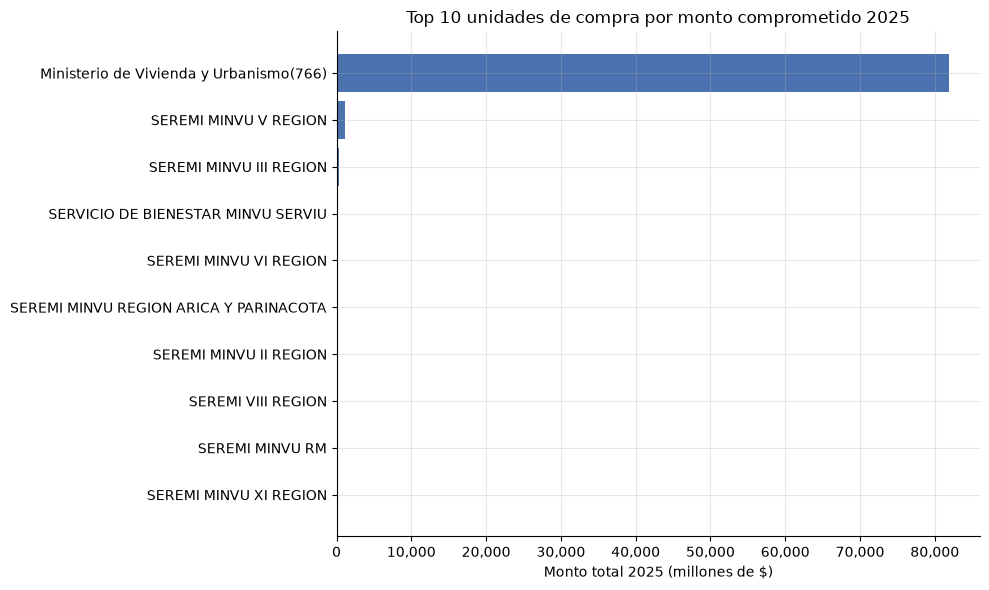

In [24]:
top_unidades = (
    df.groupby("Unidad de Compra")["Monto Total Ítem Año 2025"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_unidades.index, top_unidades.to_numpy(), color="#4C72B0")
eje_millones(ax, "x")
ax.set_xlabel("Monto total 2025 (millones de $)")
ax.set_title("Top 10 unidades de compra por monto comprometido 2025")
plt.tight_layout()
plt.show()

### 3.2 Ítems por tipo y estado de proyecto

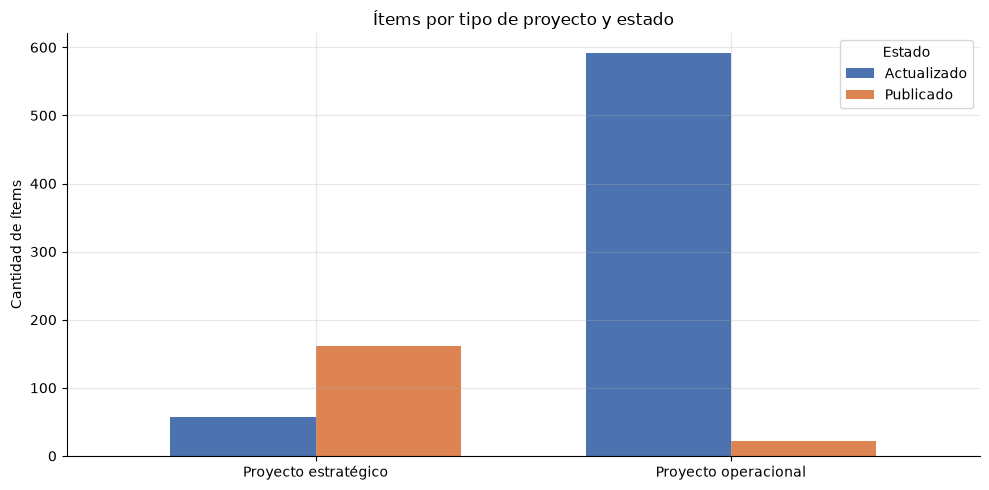

In [25]:
cruce = df.pivot_table(
    index="Tipo Proyecto",
    columns="Estado Proyecto",
    values="Nombre ítem",
    aggfunc="size",
    fill_value=0,
)

fig, ax = plt.subplots()
cruce.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"], width=0.7)
ax.set_ylabel("Cantidad de ítems")
ax.set_xlabel("")
ax.set_title("Ítems por tipo de proyecto y estado")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Estado")
plt.tight_layout()
plt.show()

### 3.3 Participación del monto por tipo de proyecto

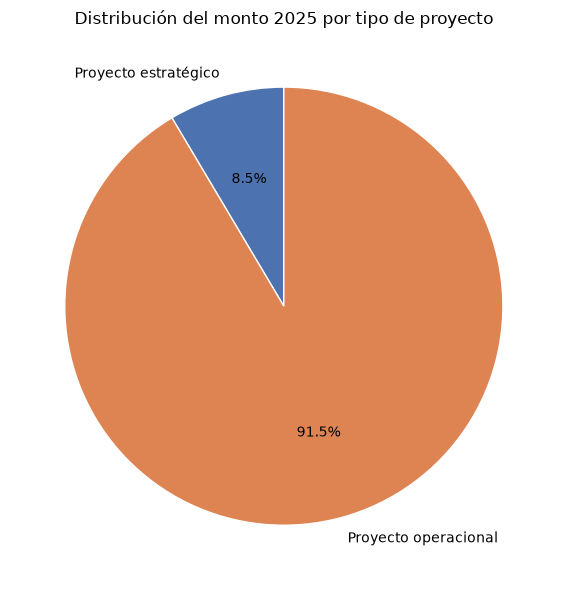

In [26]:
monto_tipo = df.groupby("Tipo Proyecto")["Monto Total Ítem Año 2025"].sum()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    monto_tipo.to_numpy(),
    labels=monto_tipo.index,
    autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452"],
    startangle=90,
    wedgeprops={"edgecolor": "white"},
)
ax.set_title("Distribución del monto 2025 por tipo de proyecto")
plt.tight_layout()
plt.show()

### 3.4 Distribución de los montos (escala logarítmica)

Los montos están muy sesgados, por eso se grafican en log10.

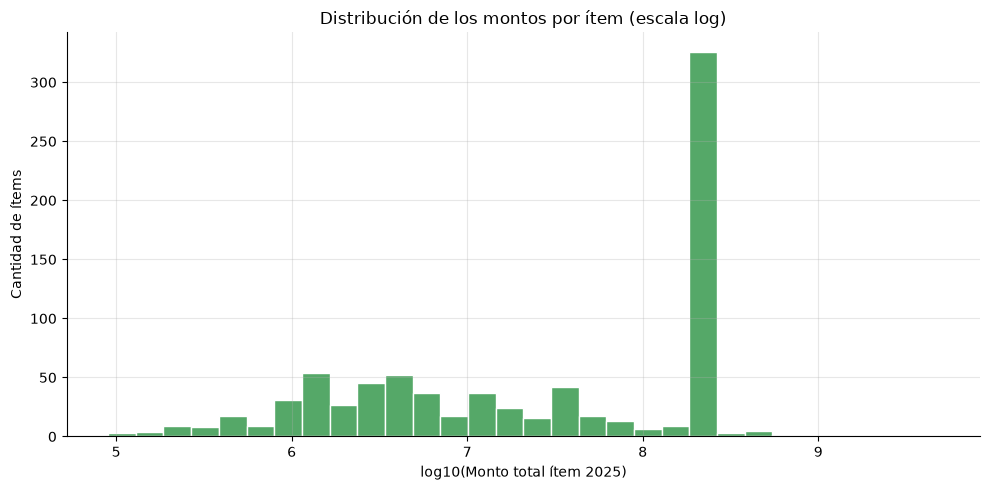

In [27]:
montos_positivos = df.loc[df["Monto Total Ítem Año 2025"] > 0, "Monto Total Ítem Año 2025"]

fig, ax = plt.subplots()
ax.hist(np.log10(montos_positivos), bins=30, color="#55A868", edgecolor="white")
ax.set_xlabel("log10(Monto total ítem 2025)")
ax.set_ylabel("Cantidad de ítems")
ax.set_title("Distribución de los montos por ítem (escala log)")
plt.tight_layout()
plt.show()

### 3.5 Comparación de montos por tipo de proyecto (boxplot)

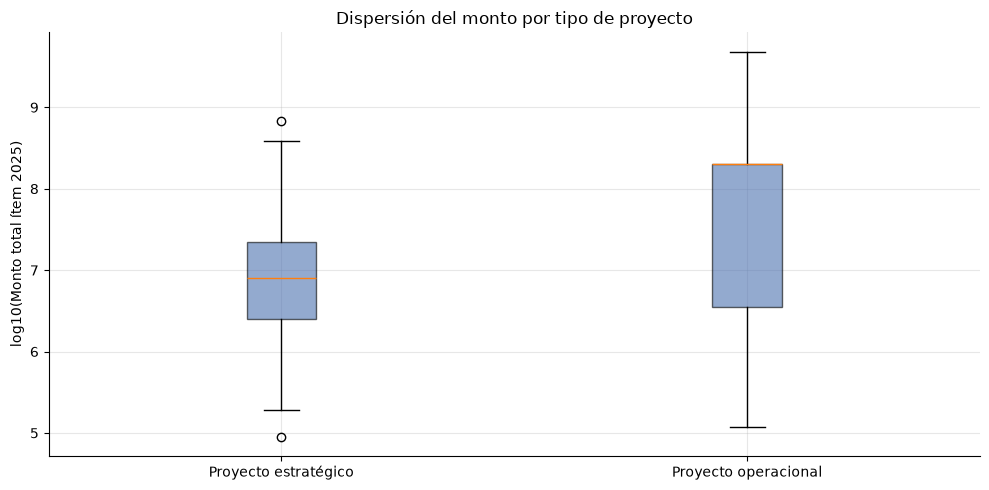

In [28]:
grupos = [
    np.log10(g.loc[g > 0])
    for _, g in df.groupby("Tipo Proyecto")["Monto Total Ítem Año 2025"]
]
etiquetas = list(df.groupby("Tipo Proyecto").groups.keys())

fig, ax = plt.subplots()
ax.boxplot(grupos, tick_labels=etiquetas, patch_artist=True,
           boxprops={"facecolor": "#4C72B0", "alpha": 0.6})
ax.set_ylabel("log10(Monto total ítem 2025)")
ax.set_title("Dispersión del monto por tipo de proyecto")
plt.tight_layout()
plt.show()

### 3.6 Ítems por tipo de compra

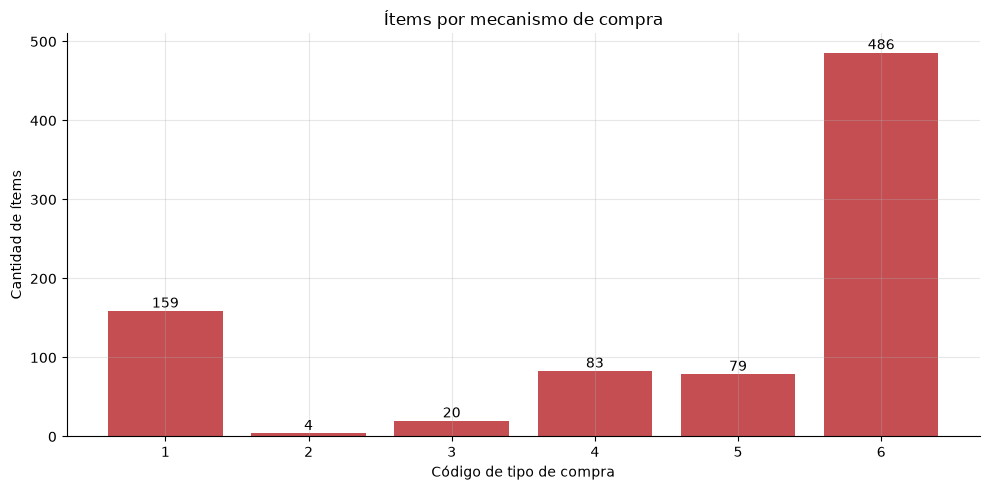

In [29]:
tipo_compra = df["Tipo compra"].value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(tipo_compra.index.astype(str), tipo_compra.to_numpy(), color="#C44E52")
for x, y in zip(tipo_compra.index.astype(str), tipo_compra.to_numpy()):
    ax.text(x, y, f"{y}", ha="center", va="bottom")
ax.set_xlabel("Código de tipo de compra")
ax.set_ylabel("Cantidad de ítems")
ax.set_title("Ítems por mecanismo de compra")
plt.tight_layout()
plt.show()

### 3.7 Evolución mensual del inicio de compras

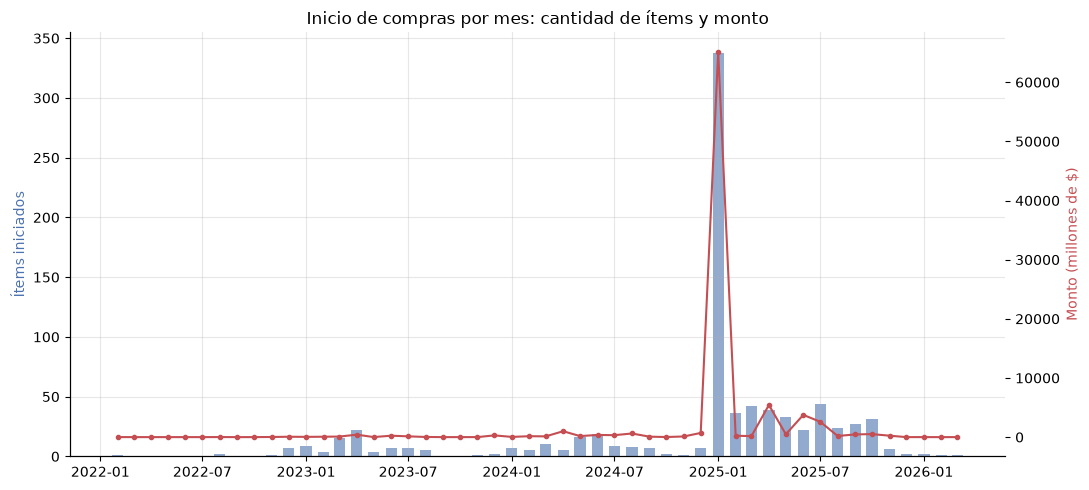

In [30]:
serie = (
    df.set_index("Fecha de Inicio Compra")
      .resample("MS")["Monto Total Ítem Año 2025"]
      .agg(["size", "sum"])
      .rename(columns={"size": "items", "sum": "monto"})
)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(serie.index, serie["items"], width=20, color="#4C72B0", alpha=0.6, label="Ítems")
ax1.set_ylabel("Ítems iniciados", color="#4C72B0")

ax2 = ax1.twinx()
ax2.plot(serie.index, serie["monto"] / MM, color="#C44E52", marker="o", ms=3, label="Monto")
ax2.set_ylabel("Monto (millones de $)", color="#C44E52")
ax2.grid(False)

ax1.set_title("Inicio de compras por mes: cantidad de ítems y monto")
plt.tight_layout()
plt.show()

**Conclusiones de los gráficos**

- El monto está muy concentrado: unas pocas unidades de compra explican casi todo
  el presupuesto del plan.
- El histograma en escala log confirma la asimetría vista en el EDA: la mayoría de
  los ítems son de montos moderados y unos pocos son de miles de millones.
- Los proyectos **estratégicos** tienen una mediana de monto superior a los
  operacionales, aunque son menos.
- El inicio de compras se concentra fuertemente en los primeros meses de 2025.

<a id="4"></a>
---
# 4. Limpieza de la columna de teléfono

`Teléfono responsable` viene con formatos mezclados:
`'2 -2901 1198-'`, `'32-2186802-'`, `'02-29011184-'`, `'322186802'`, `'0'`, …

Objetivo: normalizar a un número nacional chileno de **9 dígitos** y dejarlo
formateado como `+56 …`, marcando lo que no se puede recuperar.

### 4.1 Estado inicial de la columna

In [31]:
tel_crudo = df["Teléfono responsable"].astype(str)

print("Valores únicos:", tel_crudo.nunique())
print()
print("Muestra de 25 valores crudos:")
for v in tel_crudo.drop_duplicates().head(25):
    print(f"  {v!r}")

Valores únicos: 96

Muestra de 25 valores crudos:
  '2 -2901 1198-'
  '32-2186802-'
  '322186802'
  '02-29011184-'
  '22-901727-'
  '0'
  '22901727'
  '22-9011395-'
  '512699924'
  '722350701'
  '322350734'
  '41-2292343-'
  '412292343'
  '45-2964227-'
  '2210208'
  '229014802'
  '612299503'
  '582202525'
  '974746198'
  '58-2202529-'
  '57-2371249-'
  '72-2 350701-'
  '72-2 350712-'
  '20-9011468-1468'
  '52-2432228-'


In [32]:
# ¿qué caracteres aparecen además de los dígitos?
basura = sorted({c for v in tel_crudo for c in v if not c.isdigit()})
print("Caracteres no numéricos presentes:", basura)

solo_digitos = tel_crudo.str.replace(r"\D", "", regex=True)
print()
print("Largo (solo dígitos):")
print(solo_digitos.str.len().value_counts().sort_index())

Caracteres no numéricos presentes: [' ', '-']

Largo (solo dígitos):
Teléfono responsable
1      14
7      17
8     131
9     235
10    354
11     10
12      5
13     64
14      1
Name: count, dtype: int64


### 4.2 Reglas de normalización

En Chile el número nacional tiene **9 dígitos**:

| Tipo | Estructura | Ejemplo |
|---|---|---|
| Móvil | `9` + 8 dígitos | `974746198` |
| Fijo Santiago | `2` + 8 dígitos | `229011198` |
| Fijo regional | código de área (2 díg.) + 7 dígitos | `322186802` |

Además, los valores de 12-14 dígitos traen el **anexo pegado al final**:
`'22-9011181-1181'` = número `229011181` + anexo `1181`. Se detecta porque los
últimos 4 dígitos repiten los últimos 4 del número.

Pasos aplicados:

1. Quitar todo lo que no sea dígito.
2. Separar el anexo si los últimos 4 dígitos repiten la cola del número.
3. Quitar el prefijo país `56` si sobra largo.
4. Quitar ceros a la izquierda (`02-29011184-` → `229011184`).
5. Si quedan **9 dígitos** → válido. Si no → se marca el motivo y queda `NA`.

In [33]:
def separar_anexo(digitos):
    """'2290111811181' -> ('229011181', '1181'). Si no hay anexo, devuelve (digitos, NA)."""
    if len(digitos) > 9:
        cuerpo, cola = digitos[:-4], digitos[-4:]
        if len(cuerpo) >= 4 and cuerpo[-4:] == cola:
            return cuerpo, cola
    return digitos, pd.NA


def limpiar_telefono(valor):
    """Devuelve (numero_normalizado, anexo, estado)."""
    if valor is None or (isinstance(valor, float) and pd.isna(valor)):
        return pd.NA, pd.NA, "vacío"

    digitos = re.sub(r"\D", "", str(valor))

    if digitos == "" or set(digitos) == {"0"}:
        return pd.NA, pd.NA, "vacío"

    digitos, anexo = separar_anexo(digitos)

    # prefijo país
    if len(digitos) > 9 and digitos.startswith("56"):
        digitos = digitos[2:]

    # ceros a la izquierda (0 de larga distancia nacional)
    digitos = digitos.lstrip("0")

    if len(digitos) == 9:
        return digitos, anexo, "ok"
    if len(digitos) < 9:
        return pd.NA, anexo, f"muy corto ({len(digitos)} díg.)"
    return pd.NA, anexo, f"muy largo ({len(digitos)} díg.)"


def codigo_area(numero):
    """Móvil -> '9'; Santiago -> '2'; resto -> los dos primeros dígitos."""
    if pd.isna(numero):
        return pd.NA
    return numero[0] if numero[0] in "92" else numero[:2]


def tipo_telefono(numero):
    if pd.isna(numero):
        return "sin dato"
    if numero.startswith("9"):
        return "móvil"
    return "fijo Santiago" if numero.startswith("2") else "fijo regional"


def formatear_telefono(numero):
    """229011198 -> '+56 2 2901 1198'   |   322186802 -> '+56 32 218 6802'"""
    if pd.isna(numero):
        return pd.NA
    area = codigo_area(numero)
    resto = numero[len(area):]
    if len(area) == 1:            # móvil o Santiago: 1 + 4 + 4
        return f"+56 {area} {resto[:4]} {resto[4:]}"
    return f"+56 {area} {resto[:3]} {resto[3:]}"   # regional: 2 + 3 + 4

### 4.3 Aplicar la limpieza

In [34]:
limpieza = df["Teléfono responsable"].map(limpiar_telefono)

df["telefono_normalizado"] = [n for n, _, _ in limpieza]
df["telefono_anexo"] = [a for _, a, _ in limpieza]
df["telefono_estado"] = [e for _, _, e in limpieza]
df["telefono_formateado"] = df["telefono_normalizado"].map(formatear_telefono)
df["telefono_tipo"] = df["telefono_normalizado"].map(tipo_telefono)

df[["Teléfono responsable", "telefono_normalizado", "telefono_anexo",
    "telefono_formateado", "telefono_tipo", "telefono_estado"]].head(15)

,Teléfono responsable,telefono_normalizado,telefono_anexo,telefono_formateado,telefono_tipo,telefono_estado
0,2 -2901 1198-,229011198,NaN,+56 2 2901 1198,fijo Santiago,ok
1,32-2186802-,322186802,NaN,+56 32 218 6802,fijo regional,ok
2,32-2186802-,322186802,NaN,+56 32 218 6802,fijo regional,ok
3,32-2186802-,322186802,NaN,+56 32 218 6802,fijo regional,ok
4,322186802,322186802,NaN,+56 32 218 6802,fijo regional,ok
5,02-29011184-,229011184,NaN,+56 2 2901 1184,fijo Santiago,ok
6,22-901727-,NaN,NaN,NaN,sin dato,muy corto (8 díg.)
7,0,NaN,NaN,NaN,sin dato,vacío
8,0,NaN,NaN,NaN,sin dato,vacío
9,22901727,NaN,NaN,NaN,sin dato,muy corto (8 díg.)


In [35]:
# los casos con anexo detectado
(df.loc[df["telefono_anexo"].notna(),
        ["Teléfono responsable", "telefono_normalizado",
         "telefono_anexo", "telefono_formateado", "telefono_estado"]]
   .drop_duplicates()
   .head(15))

,Teléfono responsable,telefono_normalizado,telefono_anexo,telefono_formateado,telefono_estado
115,20-9011468-1468,209011468,1468,+56 2 0901 1468,ok
401,22-9011181-1181,229011181,1181,+56 2 2901 1181,ok
731,22-9011325-1325,229011325,1325,+56 2 2901 1325,ok
733,22-9011264-1264,229011264,1264,+56 2 2901 1264,ok
752,22-9011248-1248,229011248,1248,+56 2 2901 1248,ok
754,22-9012248-2248,229012248,2248,+56 2 2901 2248,ok
789,22-29011727-1727,NaN,1727,NaN,muy largo (10 díg.)
790,22-9011170-1170,229011170,1170,+56 2 2901 1170,ok
795,2 -2901 1170-1170,229011170,1170,+56 2 2901 1170,ok
798,2-29011325-1325,229011325,1325,+56 2 2901 1325,ok


### 4.4 Resultado de la limpieza

In [36]:
resultado = df["telefono_estado"].value_counts()
pd.DataFrame({
    "registros": resultado,
    "pct": (resultado / len(df) * 100).round(2),
})

,registros,pct
telefono_estado,,
ok,660,79.42
muy corto (8 díg.),136,16.37
muy corto (7 díg.),17,2.05
vacío,14,1.68
muy largo (10 díg.),3,0.36
muy largo (13 díg.),1,0.12


In [37]:
validos = (df["telefono_estado"] == "ok").sum()
print(f"Teléfonos recuperados : {validos} de {len(df)} ({validos / len(df):.1%})")
print()
print("Por tipo de línea:")
print(df.loc[df["telefono_estado"] == "ok", "telefono_tipo"].value_counts())

Teléfonos recuperados : 660 de 831 (79.4%)

Por tipo de línea:
telefono_tipo
fijo Santiago    525
fijo regional    125
móvil             10
Name: count, dtype: int64


### 4.5 Casos que no se pudieron recuperar

In [38]:
problemas = (
    df.loc[df["telefono_estado"] != "ok",
           ["Nombre responsable", "Teléfono responsable", "telefono_estado"]]
      .drop_duplicates()
      .sort_values("telefono_estado")
)
print("Casos distintos con problema:", len(problemas))
problemas.head(30)

Casos distintos con problema: 31


,Nombre responsable,Teléfono responsable,telefono_estado
66,Angela Chavez Oyarzo,2210208,muy corto (7 díg.)
213,"ZURITA CONTRERAS, SEBASTIAN ELIAS",90-11370-,muy corto (7 díg.)
255,"BROWN MAGNAN, PHILLIP",29-01240-,muy corto (7 díg.)
257,"Carrasco Seplveda, Fernando Antonio",29-01141-,muy corto (7 díg.)
273,"ORTIZ ARRIETA, MACARENA PAZ",29-01223-,muy corto (7 díg.)
302,"AMIGO LARENAS, CAROLINA BEATRIZ",29-01148-,muy corto (7 díg.)
6,Victor Silva Aguilar,22-901727-,muy corto (8 díg.)
9,Victor Silva Aguilar,22901727,muy corto (8 díg.)
186,PAULINA CARCENAC MARIANGEL,29-011170-,muy corto (8 díg.)
190,CARCENAC MARIANGEL PAULINA,29-011170-,muy corto (8 díg.)


### 4.6 Antes / después de los casos más sucios

In [39]:
(df.loc[df["Teléfono responsable"].astype(str).str.contains(r"[^0-9]", regex=True),
        ["Teléfono responsable", "telefono_normalizado", "telefono_formateado"]]
   .drop_duplicates()
   .head(20))

,Teléfono responsable,telefono_normalizado,telefono_formateado
0,2 -2901 1198-,229011198,+56 2 2901 1198
1,32-2186802-,322186802,+56 32 218 6802
5,02-29011184-,229011184,+56 2 2901 1184
6,22-901727-,NaN,NaN
17,22-9011395-,229011395,+56 2 2901 1395
55,41-2292343-,412292343,+56 41 229 2343
65,45-2964227-,452964227,+56 45 296 4227
86,58-2202529-,582202529,+56 58 220 2529
93,57-2371249-,572371249,+56 57 237 1249
99,72-2 350701-,722350701,+56 72 235 0701


### 4.7 Códigos de área encontrados

In [40]:
REGIONES = {
    "2": "Santiago (RM)", "9": "móvil", "32": "Valparaíso", "33": "Los Andes",
    "34": "San Felipe", "35": "Quillota", "41": "Concepción", "42": "Chillán",
    "43": "Los Ángeles", "45": "Temuco", "51": "La Serena", "52": "Copiapó",
    "53": "Ovalle", "55": "Antofagasta", "57": "Iquique", "58": "Arica",
    "61": "Punta Arenas", "63": "Valdivia", "64": "Osorno", "65": "Puerto Montt",
    "67": "Coyhaique", "71": "Talca", "72": "Rancagua", "73": "Linares",
    "75": "Curicó",
}

areas = (
    df.loc[df["telefono_estado"] == "ok", "telefono_normalizado"]
      .map(codigo_area)
      .value_counts()
      .to_frame("teléfonos")
)
areas["zona"] = [REGIONES.get(c, "código no reconocido") for c in areas.index]
areas

,teléfonos,zona
telefono_normalizado,,
2,525,Santiago (RM)
32,30,Valparaíso
52,25,Copiapó
72,20,Rancagua
51,14,La Serena
9,10,móvil
58,9,Arica
55,8,Antofagasta
57,7,Iquique


**Conclusiones de la limpieza**

- La columna original **no sirve tal cual**: mezcla guiones sobrantes al final,
  espacios internos, ceros de larga distancia, valores `0` y el **anexo pegado**
  al número.
- Con cuatro reglas (quitar no-dígitos → separar anexo → quitar prefijo 56 →
  quitar ceros iniciales) se recuperan **660 de 831 registros (79,4 %)** a 9 dígitos.
  Separar el anexo por sí solo rescata 63 de los 64 registros de 13 dígitos.
- Los casos irrecuperables son **ambiguos**, no arreglables sin la fuente original:
  - `29-011170-` (8 díg., 136 registros): a un número de Santiago le falta un
    dígito, pero no se puede saber si es `229011170` o un móvil truncado → `NA`.
  - `02-290111082-` (10 díg.): tiene un dígito de más.
- Ojo con `20-9011468-1468`: pasa la validación de largo (`209011468`) pero el
  código de área `20` no existe en Chile — es un tipeo de `22-9011468`. El largo
  correcto **no** garantiza que el número sea válido.
- Se privilegia **marcar el motivo** en `telefono_estado` antes que inventar un valor.
- Columnas nuevas: `telefono_normalizado`, `telefono_anexo`, `telefono_formateado`,
  `telefono_tipo` y `telefono_estado`.

<a id="5"></a>
---
# 5. Análisis de fechas

Columnas de fecha del plan:

- `Fecha de Inicio Compra`
- `Fecha Publicación PAC 2025`
- `Meses envio OC de Arraste`
- `Meses envío OC` → texto con **varias** fechas por celda y formatos mezclados

### 5.1 Rango de cada columna de fecha

In [41]:
cols_fecha = [c for c in df.columns if pd.api.types.is_datetime64_any_dtype(df[c])]

pd.DataFrame({
    "columna": cols_fecha,
    "minimo": [df[c].min() for c in cols_fecha],
    "maximo": [df[c].max() for c in cols_fecha],
    "nulos": [int(df[c].isna().sum()) for c in cols_fecha],
})

,columna,minimo,maximo,nulos
0,Fecha de Inicio Compra,2022-02-01,2026-03-01,0
1,Fecha Publicación PAC 2025,2022-11-08,2025-11-27,0
2,Meses envio OC de Arraste,2025-01-01,2025-12-01,648


### 5.2 Componentes de la fecha de inicio de compra

In [42]:
f = df["Fecha de Inicio Compra"]
df["inicio_anio"] = f.dt.year
df["inicio_mes"] = f.dt.month
df["inicio_trimestre"] = f.dt.quarter
df["inicio_periodo"] = f.dt.to_period("M").astype(str)
df["inicio_dia_semana"] = f.dt.day_name()

df[["Fecha de Inicio Compra", "inicio_anio", "inicio_mes",
    "inicio_trimestre", "inicio_periodo"]].head()

,Fecha de Inicio Compra,inicio_anio,inicio_mes,inicio_trimestre,inicio_periodo
0,2022-11-01,2022,11,4,2022-11
1,2022-02-01,2022,2,1,2022-02
2,2022-08-01,2022,8,3,2022-08
3,2022-08-01,2022,8,3,2022-08
4,2022-12-01,2022,12,4,2022-12


In [43]:
por_anio_inicio = (
    df.groupby("inicio_anio")
      .agg(items=("Nombre ítem", "size"),
           monto=("Monto Total Ítem Año 2025", "sum"))
)
por_anio_inicio["pct_items"] = (por_anio_inicio["items"] / por_anio_inicio["items"].sum() * 100).round(1)
por_anio_inicio

,items,monto,pct_items
inicio_anio,,,
2022,11,95266580,1.3
2023,76,1308493188,9.1
2024,96,3698381416,11.6
2025,644,79232141166,77.5
2026,4,0,0.5


Hay compras que **inician en 2022-2024** (arrastres) y otras con inicio programado en **2026**.

In [44]:
df.pivot_table(
    index="inicio_anio",
    columns="inicio_trimestre",
    values="Nombre ítem",
    aggfunc="size",
    fill_value=0,
)

inicio_trimestre,1,2,3,4
inicio_anio,,,,
2022,1,0,2,8
2023,28,33,12,3
2024,22,40,24,10
2025,416,94,95,39
2026,4,0,0,0


### 5.3 Estacionalidad mensual (solo compras que inician en 2025)

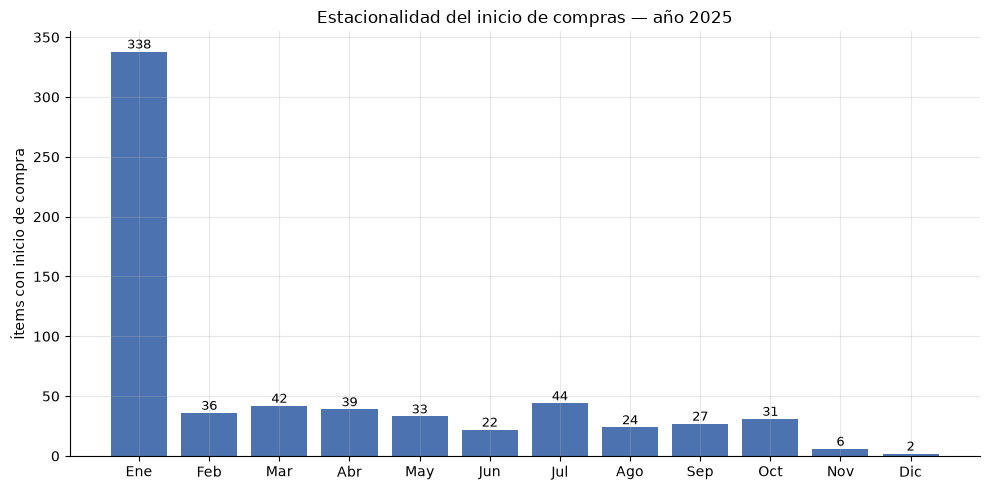

In [45]:
mes_2025 = (
    df.loc[df["inicio_anio"] == 2025]
      .groupby("inicio_mes")
      .size()
      .reindex(range(1, 13), fill_value=0)
)

fig, ax = plt.subplots()
ax.bar(MESES, mes_2025.to_numpy(), color="#4C72B0")
for x, y in zip(MESES, mes_2025.to_numpy()):
    if y:
        ax.text(x, y, str(y), ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Ítems con inicio de compra")
ax.set_title("Estacionalidad del inicio de compras — año 2025")
plt.tight_layout()
plt.show()

### 5.4 Desfase entre la publicación del PAC y el inicio de la compra

In [46]:
df["dias_pac_a_inicio"] = (
    df["Fecha de Inicio Compra"] - df["Fecha Publicación PAC 2025"]
).dt.days

print(df["dias_pac_a_inicio"].describe().round(1))
print()
print("Ítems que inician ANTES de publicarse el PAC:",
      int((df["dias_pac_a_inicio"] < 0).sum()))

count    831.0
mean    -243.1
std      100.0
min     -363.0
25%     -330.0
50%     -273.0
75%     -151.0
max       94.0
Name: dias_pac_a_inicio, dtype: float64

Ítems que inician ANTES de publicarse el PAC: 815


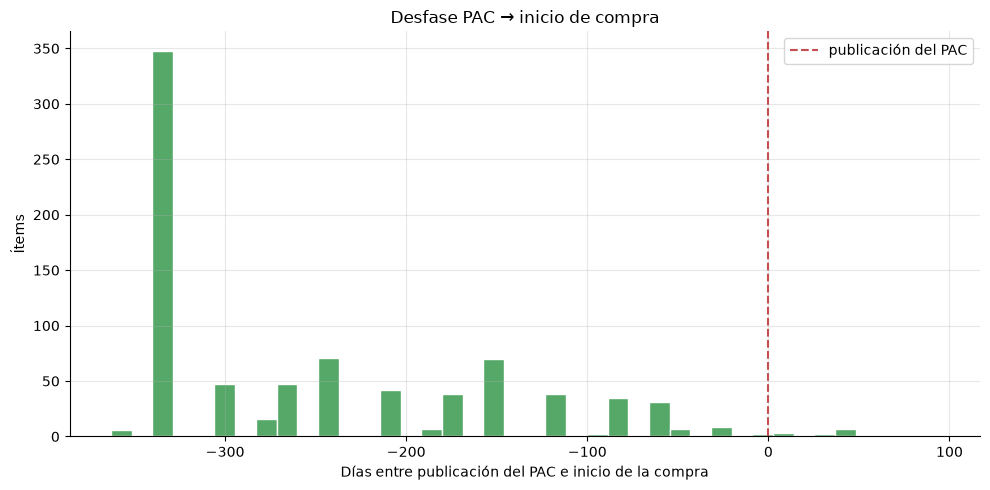

In [47]:
fig, ax = plt.subplots()
ax.hist(df["dias_pac_a_inicio"], bins=40, color="#55A868", edgecolor="white")
ax.axvline(0, color="#C44E52", ls="--", lw=1.5, label="publicación del PAC")
ax.set_xlabel("Días entre publicación del PAC e inicio de la compra")
ax.set_ylabel("Ítems")
ax.set_title("Desfase PAC → inicio de compra")
ax.legend()
plt.tight_layout()
plt.show()

### 5.5 Parseo de `Meses envío OC`

Esta columna guarda **una lista de fechas** en una sola celda, con tres formatos
distintos conviviendo:

- `'Abr 2023,Ene 2024,Ene 2025'` → mes abreviado en español + año
- `'01-09-2023,01-01-2024,01-01-2025'` → `dd-mm-aaaa`
- `'2023-07-01 00:00:00'` → timestamp ISO

In [48]:
MES_ES = {
    "ene": 1, "feb": 2, "mar": 3, "abr": 4, "may": 5, "jun": 6,
    "jul": 7, "ago": 8, "sep": 9, "sept": 9, "oct": 10, "nov": 11, "dic": 12,
}


def parsear_token(token):
    """Convierte un token suelto en Timestamp (o NaT si no se reconoce)."""
    token = token.strip()
    if not token:
        return pd.NaT

    # 'Abr 2023'
    m = re.match(r"^([A-Za-zÁÉÍÓÚáéíóúñ]+)\s+(\d{4})$", token)
    if m and m.group(1).lower() in MES_ES:
        return pd.Timestamp(year=int(m.group(2)), month=MES_ES[m.group(1).lower()], day=1)

    # '01-09-2023'  (dd-mm-aaaa)
    m = re.match(r"^(\d{1,2})-(\d{1,2})-(\d{4})$", token)
    if m:
        d, mes, a = (int(g) for g in m.groups())
        return pd.Timestamp(year=a, month=mes, day=d)

    # ISO / timestamp
    try:
        return pd.Timestamp(token).normalize()
    except (ValueError, TypeError):
        return pd.NaT


def parsear_meses_oc(celda):
    if celda is None or (isinstance(celda, float) and pd.isna(celda)):
        return []
    return [f for f in (parsear_token(t) for t in str(celda).split(",")) if pd.notna(f)]


df["fechas_oc"] = df["Meses envío OC"].map(parsear_meses_oc)
df["n_fechas_oc"] = df["fechas_oc"].map(len)

df[["Meses envío OC", "fechas_oc", "n_fechas_oc", "Cantidad OC"]].head(8)

,Meses envío OC,fechas_oc,n_fechas_oc,Cantidad OC
0,"Abr 2023,Ene 2024,Ene 2025","[2023-04-01 00:00:00, 2024-01-01 00:00:00, 202...",3,3
1,"May 2022,Nov 2022,Ene 2023,Ene 2024,Ene 2025","[2022-05-01 00:00:00, 2022-11-01 00:00:00, 202...",5,5
2,"Oct 2022,Ene 2023,Ene 2024,Ene 2025","[2022-10-01 00:00:00, 2023-01-01 00:00:00, 202...",4,4
3,"Oct 2022,Nov 2022,Dic 2022,Ene 2023,Ene 2024,E...","[2022-10-01 00:00:00, 2022-11-01 00:00:00, 202...",6,6
4,"Ene 2023,Ene 2024,Ene 2025,Ene 2026","[2023-01-01 00:00:00, 2024-01-01 00:00:00, 202...",4,4
5,"01-09-2023,01-01-2024,01-01-2025","[2023-09-01 00:00:00, 2024-01-01 00:00:00, 202...",3,3
6,"01-01-2024,01-01-2025","[2024-01-01 00:00:00, 2025-01-01 00:00:00]",2,3
7,2023-07-01 00:00:00,[2023-07-01 00:00:00],1,1


In [49]:
sin_parsear = df.loc[df["n_fechas_oc"] == 0, "Meses envío OC"].unique()
print("Celdas que no se pudieron parsear:", len(sin_parsear))
print(sin_parsear[:10])
print()
print("Coincidencia con la columna 'Cantidad OC':",
      f"{(df['n_fechas_oc'] == df['Cantidad OC']).mean():.1%}")

Celdas que no se pudieron parsear: 0
[]

Coincidencia con la columna 'Cantidad OC': 90.7%


#### Calendario de órdenes de compra (formato largo)

In [50]:
calendario = (
    df[["ID Proyecto", "Unidad de Compra", "Nombre ítem",
        "Monto Total Ítem Año 2025", "fechas_oc"]]
    .explode("fechas_oc")
    .dropna(subset=["fechas_oc"])
    .rename(columns={"fechas_oc": "fecha_oc"})
)
calendario["anio_oc"] = calendario["fecha_oc"].dt.year
calendario["mes_oc"] = calendario["fecha_oc"].dt.month

print("Órdenes de compra programadas:", len(calendario))
calendario.head()

Órdenes de compra programadas: 1108


,ID Proyecto,Unidad de Compra,Nombre ítem,Monto Total Ítem Año 2025,fecha_oc,anio_oc,mes_oc
0,587-259-PC22,Ministerio de Vivienda y Urbanismo(766),Servicio arriendo de una plataforma de gestión...,20000000,2023-04-01,2023,4
0,587-259-PC22,Ministerio de Vivienda y Urbanismo(766),Servicio arriendo de una plataforma de gestión...,20000000,2024-01-01,2024,1
0,587-259-PC22,Ministerio de Vivienda y Urbanismo(766),Servicio arriendo de una plataforma de gestión...,20000000,2025-01-01,2025,1
1,632-28-PC22,SEREMI MINVU V REGION,Mantenimiento y Reparación de Edificaciones,4500000,2022-05-01,2022,5
1,632-28-PC22,SEREMI MINVU V REGION,Mantenimiento y Reparación de Edificaciones,4500000,2022-11-01,2022,11


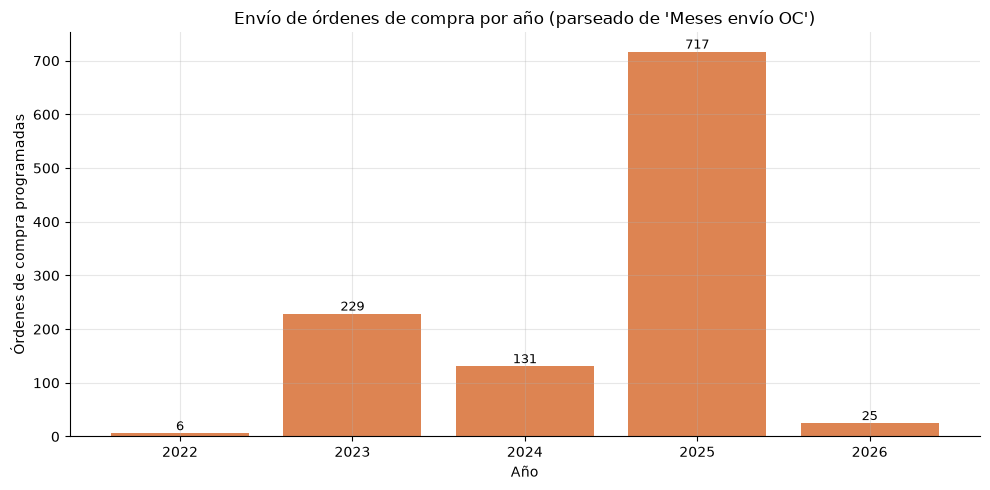

In [51]:
oc_por_anio = calendario["anio_oc"].value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(oc_por_anio.index.astype(str), oc_por_anio.to_numpy(), color="#DD8452")
for x, y in zip(oc_por_anio.index.astype(str), oc_por_anio.to_numpy()):
    ax.text(x, y, str(y), ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Año")
ax.set_ylabel("Órdenes de compra programadas")
ax.set_title("Envío de órdenes de compra por año (parseado de 'Meses envío OC')")
plt.tight_layout()
plt.show()

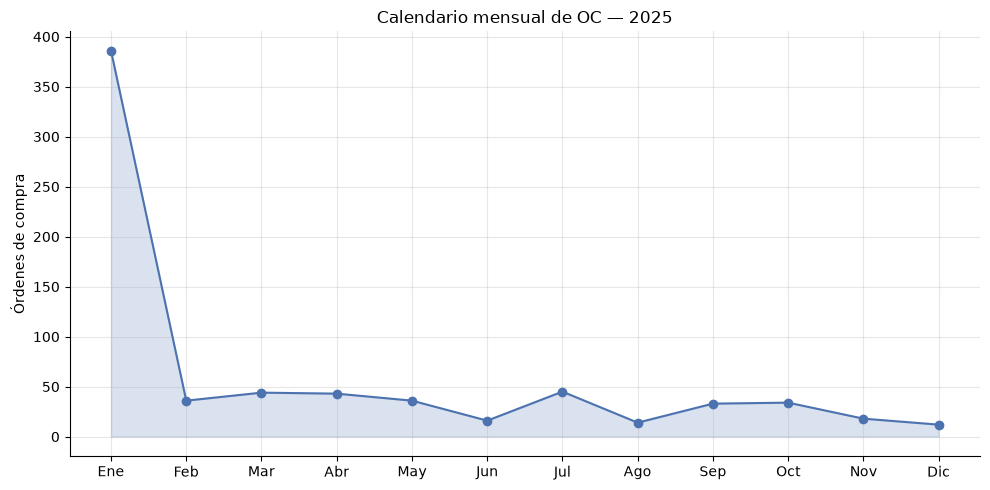

In [52]:
oc_2025 = (
    calendario.loc[calendario["anio_oc"] == 2025]
    .groupby("mes_oc")
    .size()
    .reindex(range(1, 13), fill_value=0)
)

fig, ax = plt.subplots()
ax.plot(MESES, oc_2025.to_numpy(), marker="o", color="#4C72B0")
ax.fill_between(MESES, oc_2025.to_numpy(), alpha=0.2, color="#4C72B0")
ax.set_ylabel("Órdenes de compra")
ax.set_title("Calendario mensual de OC — 2025")
plt.tight_layout()
plt.show()

### 5.6 Ítems de arrastre y su mes de OC

In [53]:
arrastre = df.dropna(subset=["Meses envio OC de Arraste"]).copy()
arrastre["mes_arrastre"] = arrastre["Meses envio OC de Arraste"].dt.month

resumen_arrastre = (
    arrastre.groupby("mes_arrastre")
    .agg(items=("Nombre ítem", "size"),
         monto=("Monto De Arrastre", "sum"))
    .reindex(range(1, 13), fill_value=0)
)
resumen_arrastre.index = MESES
resumen_arrastre

,items,monto
Ene,144,2726371514
Feb,10,646958336
Mar,6,342644667
Abr,6,323833333
May,2,103000000
Jun,5,720666666
Jul,2,4444446
Ago,0,0
Sep,0,0
Oct,1,5333333


**Conclusiones del análisis de fechas**

- El plan 2025 mezcla compras **nuevas** con **arrastres**: hay fechas de inicio
  desde 2022 y hasta 2026. El 77,5 % de los ítems inicia en 2025 y de esos la
  mayoría cae en el **primer trimestre**.
- El desfase PAC → inicio es negativo en **815 de 831 ítems** (mediana: −273 días).
  No es un error de datos: `Fecha Publicación PAC 2025` es un dato **a nivel de
  plan**, no del ítem, así que casi todas las compras ya estaban en marcha cuando
  se publicó el PAC.
- `Meses envío OC` requiere un parser propio porque conviven tres formatos de fecha
  en la misma columna; una vez normalizada permite armar el **calendario de OC**
  en formato largo (una fila por orden de compra programada).

<a id="6"></a>
---
# 6. Filtrar por código de proyecto según el año

> *filtrar por codigo proyecto segun año (ultimos 3 digitos es el año) FC25.
> filtrar solo mostrar año 25.*

El `ID Proyecto` tiene la forma `UNIDAD-CORRELATIVO-PCAA`, por ejemplo
`1583-164-PC23`. El sufijo final codifica el año: **`PC25` → año 2025**.
Los dos últimos caracteres son los dígitos del año.

### 6.1 Anatomía del `ID Proyecto`

In [54]:
print("Ejemplos de ID Proyecto:")
for v in df["ID Proyecto"].drop_duplicates().head(10):
    print("  ", v)

print()
print("Sufijos presentes (últimos 4 caracteres):")
print(df["ID Proyecto"].str[-4:].value_counts())

Ejemplos de ID Proyecto:
   587-259-PC22
   632-28-PC22
   632-32-PC22
   632-34-PC22
   632-41-PC22
   1583-164-PC23
   1583-172-PC23
   1583-178-PC23
   1583-184-PC23
   1583-301-PC23

Sufijos presentes (últimos 4 caracteres):
ID Proyecto
PC25    648
PC24     97
PC23     81
PC22      5
Name: count, dtype: int64


### 6.2 Extraer el año con expresión regular

In [55]:
PATRON = r"^(?P<unidad>\d+)-(?P<correlativo>\d+)-(?P<prefijo>[A-Z]{2})(?P<anio>\d{2})$"

partes = df["ID Proyecto"].str.extract(PATRON)
print("IDs que NO calzan con el patrón:", int(partes["anio"].isna().sum()))

df[["cod_unidad", "cod_correlativo", "cod_prefijo", "cod_anio"]] = partes
df["anio_proyecto"] = df["cod_anio"].astype(int) + 2000

df[["ID Proyecto", "cod_unidad", "cod_correlativo",
    "cod_prefijo", "cod_anio", "anio_proyecto"]].head(10)

IDs que NO calzan con el patrón: 0


,ID Proyecto,cod_unidad,cod_correlativo,cod_prefijo,cod_anio,anio_proyecto
0,587-259-PC22,587,259,PC,22,2022
1,632-28-PC22,632,28,PC,22,2022
2,632-32-PC22,632,32,PC,22,2022
3,632-34-PC22,632,34,PC,22,2022
4,632-41-PC22,632,41,PC,22,2022
5,1583-164-PC23,1583,164,PC,23,2023
6,1583-172-PC23,1583,172,PC,23,2023
7,1583-178-PC23,1583,178,PC,23,2023
8,1583-178-PC23,1583,178,PC,23,2023
9,1583-184-PC23,1583,184,PC,23,2023


### 6.3 Distribución de ítems por año del proyecto

In [56]:
distribucion = (
    df.groupby(["cod_prefijo", "anio_proyecto"])
      .agg(items=("Nombre ítem", "size"),
           proyectos=("ID Proyecto", "nunique"),
           monto=("Monto Total Ítem Año 2025", "sum"))
)
distribucion["pct_items"] = (distribucion["items"] / len(df) * 100).round(1)
distribucion.assign(monto=lambda d: d["monto"].map(clp))

items  proyectos            monto  pct_items
cod_prefijo anio_proyecto                                              
PC          2022               5          5      $59.225.000        0.6
            2023              81         29   $1.064.534.768        9.7
            2024              97         44   $3.978.381.416       11.7
            2025             648        248  $79.232.141.166       78.0

### 6.4 Filtro: solo proyectos del año **25**

In [57]:
ANIO = 25

df_25 = df[df["cod_anio"] == f"{ANIO:02d}"].copy()

print(f"Filtro aplicado: ID Proyecto terminado en '{ANIO:02d}'")
print(f"Ítems original : {len(df):,}")
print(f"Ítems año {ANIO}  : {len(df_25):,}  ({len(df_25) / len(df):.1%})")
print(f"Proyectos       : {df_25['ID Proyecto'].nunique():,}")

Filtro aplicado: ID Proyecto terminado en '25'
Ítems original : 831
Ítems año 25  : 648  (78.0%)
Proyectos       : 248


In [58]:
# alternativas equivalentes al mismo filtro
alt_endswith = df[df["ID Proyecto"].str.endswith("25")]
alt_regex = df[df["ID Proyecto"].str.contains(r"PC25$", regex=True)]
alt_slice = df[df["ID Proyecto"].str[-2:] == "25"]

print("str.endswith('25') :", len(alt_endswith))
print("regex 'PC25$'      :", len(alt_regex))
print("slice [-2:] == '25':", len(alt_slice))
print("todas coinciden    :", len({len(alt_endswith), len(alt_regex), len(alt_slice), len(df_25)}) == 1)

str.endswith('25') : 648
regex 'PC25$'      : 648
slice [-2:] == '25': 648
todas coinciden    : True


### 6.5 El resultado del filtro

In [59]:
df_25[["ID Proyecto", "Unidad de Compra", "Tipo Proyecto", "Estado Proyecto",
       "Nombre ítem", "Monto Total Ítem Año 2025"]].head(20)

,ID Proyecto,Unidad de Compra,Tipo Proyecto,Estado Proyecto,Nombre ítem,Monto Total Ítem Año 2025
183,1583-4-PC25,Ministerio de Vivienda y Urbanismo(766),Proyecto operacional,Actualizado,INSUMOS PARA DISPENSADORES-3 - ADMINISTRACIÓN ...,47941530
184,1583-4-PC25,Ministerio de Vivienda y Urbanismo(766),Proyecto operacional,Actualizado,INSUMOS PARA DISPENSADORES-3 - ADMINISTRACIÓN ...,47941530
185,1583-4-PC25,Ministerio de Vivienda y Urbanismo(766),Proyecto operacional,Actualizado,INSUMOS PARA DISPENSADORES-3 - ADMINISTRACIÓN ...,47941530
186,1583-5-PC25,Ministerio de Vivienda y Urbanismo(766),Proyecto operacional,Actualizado,MATERIAL DE ASEO-1 - ADMINISTRACIÓN DE INSUMOS,2300000
187,1583-5-PC25,Ministerio de Vivienda y Urbanismo(766),Proyecto operacional,Actualizado,MATERIAL DE ASEO-1 - ADMINISTRACIÓN DE INSUMOS,2300000
188,1583-5-PC25,Ministerio de Vivienda y Urbanismo(766),Proyecto operacional,Actualizado,MATERIAL DE ASEO-1 - ADMINISTRACIÓN DE INSUMOS,2300000
189,1583-5-PC25,Ministerio de Vivienda y Urbanismo(766),Proyecto operacional,Actualizado,MATERIAL DE ASEO-1 - ADMINISTRACIÓN DE INSUMOS,2300000
190,1583-6-PC25,Ministerio de Vivienda y Urbanismo(766),Proyecto operacional,Actualizado,MATERIAL DE ASEO-2 - ADMINISTRACIÓN DE INSUMOS,2500000
191,1583-8-PC25,Ministerio de Vivienda y Urbanismo(766),Proyecto operacional,Actualizado,MATERIAL DE ESCRITORIO-1 - ADMINISTRACIÓN DE I...,15000000
192,1583-8-PC25,Ministerio de Vivienda y Urbanismo(766),Proyecto operacional,Actualizado,MATERIAL DE ESCRITORIO-1 - ADMINISTRACIÓN DE I...,15000000


### 6.6 Resumen del subconjunto año 25

In [60]:
print("=== Plan de compras — proyectos año 25 ===")
print(f"Ítems             : {len(df_25):,}")
print(f"Proyectos         : {df_25['ID Proyecto'].nunique():,}")
print(f"Unidades de compra: {df_25['Unidad de Compra'].nunique()}")
print(f"Responsables      : {df_25['Nombre responsable'].nunique()}")
print(f"Monto total 2025  : {clp(df_25['Monto Total Ítem Año 2025'].sum())}")
print(f"Monto mediano     : {clp(df_25['Monto Total Ítem Año 2025'].median())}")

=== Plan de compras — proyectos año 25 ===
Ítems             : 648
Proyectos         : 248
Unidades de compra: 1
Responsables      : 52
Monto total 2025  : $79.232.141.166
Monto mediano     : $202.000.000


In [61]:
(df_25.groupby("Unidad de Compra")
      .agg(items=("Nombre ítem", "size"),
           monto=("Monto Total Ítem Año 2025", "sum"))
      .sort_values("monto", ascending=False)
      .head(10)
      .assign(monto=lambda d: d["monto"].map(clp)))

,items,monto
Unidad de Compra,,
Ministerio de Vivienda y Urbanismo(766),648,$79.232.141.166


In [62]:
(df_25.groupby(["Tipo Proyecto", "Estado Proyecto"])
      .agg(items=("Nombre ítem", "size"),
           monto=("Monto Total Ítem Año 2025", "sum"))
      .assign(monto=lambda d: d["monto"].map(clp)))

,,items,monto
Tipo Proyecto,Estado Proyecto,,
Proyecto estratégico,Actualizado,57,$2.261.706.290
Proyecto operacional,Actualizado,591,$76.970.434.876


### 6.7 Función reutilizable

In [63]:
def filtrar_por_anio(datos, anio):
    """Filtra el plan de compras por el año codificado al final del ID Proyecto.

    Parameters
    ----------
    datos : pd.DataFrame
    anio : int | str
        Año en 2 dígitos (25) o 4 dígitos (2025).

    Returns
    -------
    pd.DataFrame
    """
    aa = f"{int(anio) % 100:02d}"
    return datos[datos["ID Proyecto"].str.strip().str.endswith(aa)].copy()


for a in [2022, 2023, 2024, 2025]:
    print(f"año {a}: {len(filtrar_por_anio(df, a)):>4} ítems")

año 2022:    5 ítems
año 2023:   81 ítems
año 2024:   97 ítems
año 2025:  648 ítems


### 6.8 Exportar el resultado (opcional)

In [64]:
# descomentar para generar el archivo filtrado
# salida = Path("plan_compras_proyectos_25.xlsx")
# df_25.to_excel(salida, index=False, sheet_name="AÑO 25")
# print("Exportado:", salida.resolve())

**Conclusiones del filtro**

- El sufijo del `ID Proyecto` (`PC22`, `PC23`, `PC24`, `PC25`) identifica el año en
  que se creó el proyecto; **todos** los IDs del archivo calzan con el patrón
  `unidad-correlativo-PCaa`, así que no hay que tratar excepciones.
- Filtrando por año **25** quedan **648 de 831 ítems (78 %)** en **248 proyectos**,
  por $79.232.141.166. El resto son proyectos de años anteriores que siguen
  vigentes dentro del plan 2025 (arrastres).
- Dos hallazgos del subconjunto: **todos** los proyectos `PC25` pertenecen a una
  sola unidad de compra (Ministerio de Vivienda y Urbanismo (766)) y **todos**
  están en estado `Actualizado`. O sea, las SEREMI regionales del archivo solo
  aparecen con proyectos de años anteriores.
- Los tres métodos de filtro (`str.endswith`, regex y *slicing*) entregan el mismo
  resultado; `endswith` es el más legible y `str.extract` es preferible cuando además
  se necesitan las otras partes del código.

---
# Resumen general

| Actividad | Resultado principal |
|---|---|
| 0 — Carga | 831 ítems x 26 columnas, hoja única `PLAN DE COMPRAS 2025` |
| 1 — EDA | sin duplicados; nulos estructurales; montos muy sesgados (mediana \$35 MM, máx \$4.839 MM) |
| 2 — Tablas | el nivel central concentra el 97 % del monto; `1583-200-PC25` explica \$64.842 MM de \$84.334 MM |
| 3 — Gráficos | 7 visualizaciones; el inicio de compras se concentra en el 1er trimestre 2025 |
| 4 — Teléfonos | 660 de 831 (79,4 %) normalizados a 9 dígitos; el resto queda `NA` con motivo |
| 5 — Fechas | parser propio para `Meses envío OC` (3 formatos); 1.108 OC programadas |
| 6 — Filtro año 25 | 648 ítems (78 %), 248 proyectos, \$79.232.141.166 |

**Columnas agregadas al `DataFrame` a lo largo del notebook:**
`telefono_normalizado`, `telefono_anexo`, `telefono_formateado`, `telefono_tipo`,
`telefono_estado`, `inicio_anio`, `inicio_mes`, `inicio_trimestre`,
`inicio_periodo`, `inicio_dia_semana`, `dias_pac_a_inicio`, `fechas_oc`,
`n_fechas_oc`, `cod_unidad`, `cod_correlativo`, `cod_prefijo`, `cod_anio`,
`anio_proyecto`.